# Data Preprocessing and Augmentation

This notebook prepares data loaders with appropriate transformations for training, validation, and testing.

In [1]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.14.0+cpu
CUDA available: False


In [2]:
# Define paths
DATA_DIR = Path('../data/flowers')
BATCH_SIZE = 32
NUM_WORKERS = 4

# Image normalization for pretrained models
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

In [3]:
# Define transformations for different splits
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

In [4]:
# Create datasets using ImageFolder
train_dataset = ImageFolder(root=DATA_DIR / 'train', transform=train_transform)
val_dataset = ImageFolder(root=DATA_DIR / 'val', transform=val_transform)
test_dataset = ImageFolder(root=DATA_DIR / 'test', transform=test_transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"\nClass to index mapping (first 10):")
print(dict(list(train_dataset.class_to_idx.items())[:10]))

Training samples: 1020
Validation samples: 1020
Test samples: 6149

Class to index mapping (first 10):
{'1': 0, '10': 1, '100': 2, '101': 3, '102': 4, '11': 5, '12': 6, '13': 7, '14': 8, '15': 9}


In [5]:
# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 32
Validation batches: 32
Test batches: 193


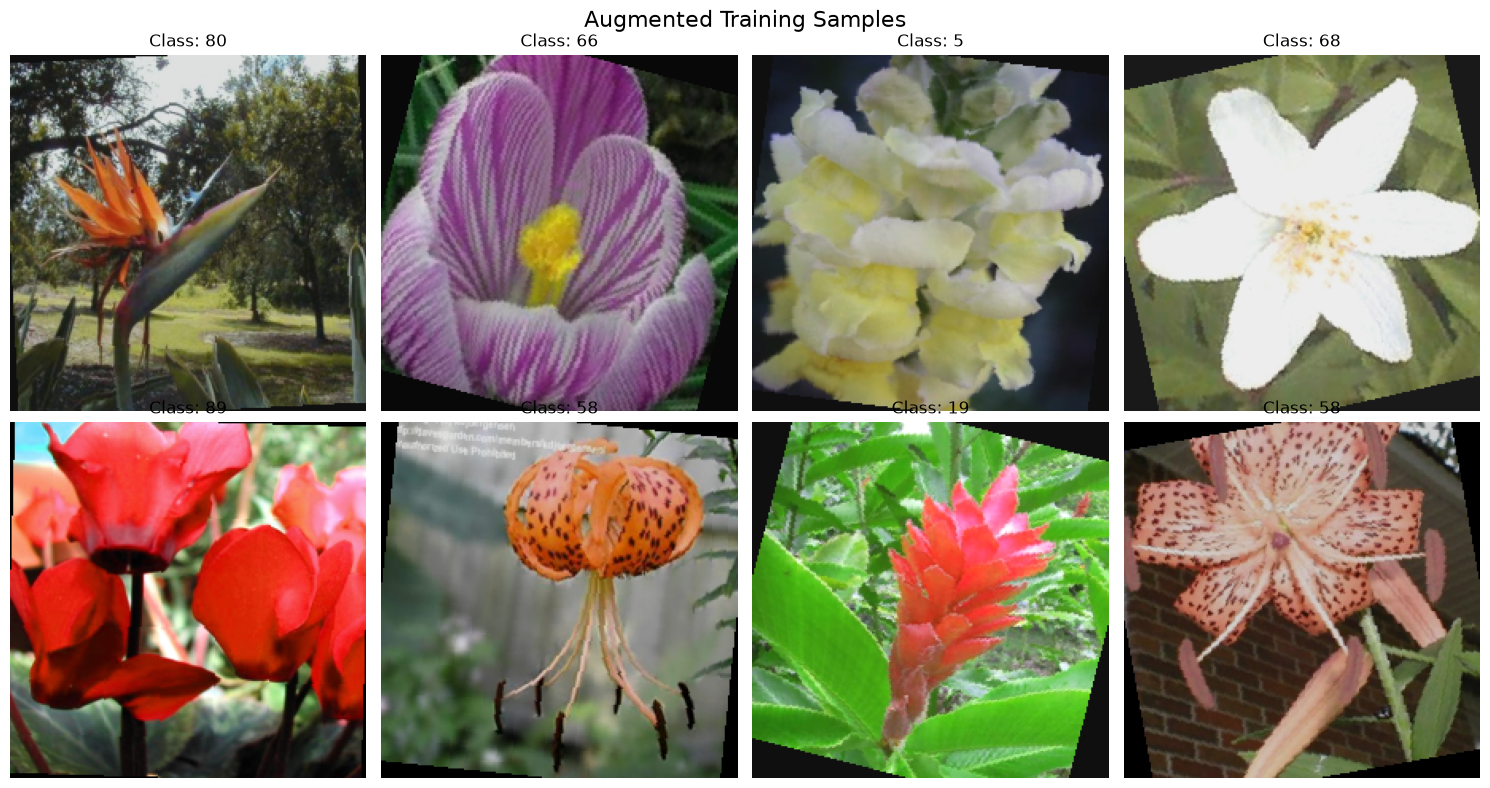

In [6]:
# Visualize augmented training samples
def denormalize(tensor):
    """Denormalize a tensor for visualization"""
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return tensor * std + mean

def show_batch(loader, num_images=8):
    images, labels = next(iter(loader))
    images = images[:num_images]
    labels = labels[:num_images]
    
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    for idx, ax in enumerate(axes.flat):
        img = denormalize(images[idx])
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(f'Class: {labels[idx].item()}')
        ax.axis('off')
    plt.suptitle('Augmented Training Samples', fontsize=16)
    plt.tight_layout()
    plt.show()

show_batch(train_loader)

In [7]:
# Save datasets for later use
torch.save({
    'train_dataset': train_dataset,
    'val_dataset': val_dataset,
    'test_dataset': test_dataset,
    'class_to_idx': train_dataset.class_to_idx
}, '../data/processed_datasets.pth')

print("Datasets saved successfully!")
print(f"Class to index mapping saved: {len(train_dataset.class_to_idx)} classes")

Datasets saved successfully!
Class to index mapping saved: 102 classes
